<a href="https://colab.research.google.com/github/prasanna-venkatesh-m/Analytics-Forecast/blob/main/Analytics_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split

Data cleaning and Perparing

In [2]:
df = pd.read_csv("/content/data.csv")

In [9]:
df.head()

,BranchID,CountofGroup,CountofAccountID,CountofCreditOfficerID,SumofPrincipalOutstanding,SumofInterestOutstanding,SumofTotalPrincipalOverdue,SumofTotalInterestOverdue,SumofTotalPAR,Date
0,1,238,238,238,2884071,298519,2836866,296178,2884071,2023-03-31
1,2,269,269,269,3342578,396290,3294740,394320,3342578,2023-03-31
2,3,149,149,149,1989393,209196,1822503,200022,1989393,2023-03-31
3,4,321,321,321,3705798,454072,3698023,453812,3705798,2023-03-31
4,5,89,89,89,1053737,108325,972575,102512,1053737,2023-03-31


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

def generate_features(group):
    group['day_of_week'] = group['Date'].dt.dayofweek
    group['day_of_month'] = group['Date'].dt.day
    group['month'] = group['Date'].dt.month

    group['lag_1'] = group['SumofPrincipalOutstanding'].shift(1)
    group['lag_7'] = group['SumofPrincipalOutstanding'].shift(7)
    group['lag_30'] = group['SumofPrincipalOutstanding'].shift(30)
    group['rolling_mean_7'] = group['SumofPrincipalOutstanding'].shift(1).rolling(window=7).mean()

    return group

df_final = df.groupby('BranchID', group_keys=False).apply(generate_features)
df_final = df_final.dropna(subset=['lag_30', 'rolling_mean_7'])

/tmp/ipykernel_52043/3559314197.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])
/tmp/ipykernel_52043/3559314197.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_final = df.groupby('BranchID', group_keys=False).apply(generate_features)


Defining the Features and Targets

In [4]:
features = ['BranchID', 'day_of_week', 'day_of_month', 'month',
            'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7']
target = 'SumofPrincipalOutstanding'

df_final['BranchID'] = df_final['BranchID'].astype('category')

split_date = df_final['Date'].max() - pd.Timedelta(days=30)
train = df_final[df_final['Date'] <= split_date]
valid = df_final[df_final['Date'] > split_date]

X_train, y_train = train[features], train[target]
X_valid, y_valid = valid[features], valid[target]

Light GBM dataset

In [5]:
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=['BranchID'])
dvalid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=['BranchID'], reference=dtrain)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42
}

model = lgb.train(params, dtrain, valid_sets=[dvalid], num_boost_round=1000)

In [6]:
def generate_forecast(model, last_data, days_to_forecast):
    forecast_df = last_data.copy()

    for _ in range(days_to_forecast):
        last_rows = forecast_df.groupby('BranchID').tail(1).copy()
        last_rows['Date'] = last_rows['Date'] + pd.Timedelta(days=1)
        last_rows['day_of_week'] = last_rows['Date'].dt.dayofweek
        last_rows['day_of_month'] = last_rows['Date'].dt.day
        last_rows['month'] = last_rows['Date'].dt.month

        preds = model.predict(last_rows[features])
        last_rows['SumofPrincipalOutstanding'] = preds

        forecast_df = pd.concat([forecast_df, last_rows])

    return forecast_df

In [27]:
def predict_future_clean(model, df_recent, days_to_predict, features):
    future_list = []
    current_buffer = df_recent.copy()

    for i in range(days_to_predict):
        next_date = current_buffer['Date'].max() + pd.Timedelta(days=1)

        last_states = current_buffer.sort_values('Date').groupby('BranchID').tail(1).copy()

        tomorrow = last_states.copy()
        tomorrow['Date'] = next_date
        tomorrow['day_of_week'] = tomorrow['Date'].dt.dayofweek
        tomorrow['day_of_month'] = tomorrow['Date'].dt.day
        tomorrow['month'] = tomorrow['Date'].dt.month

        for branch in tomorrow['BranchID'].unique():
            history = current_buffer[current_buffer['BranchID'] == branch].sort_values('Date')

            tomorrow.loc[tomorrow['BranchID'] == branch, 'lag_1'] = history['SumofPrincipalOutstanding'].iloc[-1]
            tomorrow.loc[tomorrow['BranchID'] == branch, 'lag_7'] = history['SumofPrincipalOutstanding'].iloc[-7] if len(history) >= 7 else history['SumofPrincipalOutstanding'].iloc[-1]
            tomorrow.loc[tomorrow['BranchID'] == branch, 'rolling_mean_7'] = history['SumofPrincipalOutstanding'].tail(7).mean()

        preds = model.predict(tomorrow[features])
        tomorrow['predicted_value'] = preds

        tomorrow['SumofPrincipalOutstanding'] = preds

        future_list.append(tomorrow[['Date', 'BranchID', 'predicted_value']])
        current_buffer = pd.concat([current_buffer, tomorrow]).reset_index(drop=True)

    return pd.concat(future_list)

forecast_df = predict_future_clean(model, df_final, 25, features)

/tmp/ipykernel_52043/2789693595.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  last_states = current_buffer.sort_values('Date').groupby('BranchID').tail(1).copy()
/tmp/ipykernel_52043/2789693595.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  last_states = current_buffer.sort_values('Date').groupby('BranchID').tail(1).copy()
/tmp/ipykernel_52043/2789693595.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  last

In [28]:
forecast_df = forecast_df.sort_values(['Date','BranchID'])
forecast_df.head(150)

,Date,BranchID,predicted_value
95688,2026-04-01,1,8.754515e+06
95689,2026-04-01,2,1.366433e+07
95690,2026-04-01,3,1.111448e+07
95691,2026-04-01,4,1.428472e+07
95692,2026-04-01,5,1.245643e+07
...,...,...,...
95833,2026-04-01,146,3.688146e+06
95834,2026-04-01,147,1.241067e+07
95835,2026-04-01,148,9.583278e+06
95836,2026-04-01,149,6.863186e+06


In [29]:
test_df = pd.read_csv('/content/FY2026.csv')

In [30]:
test = test_df.groupby('Date')['SumofPrincipalOutstanding'].sum().reset_index()

In [31]:
forecast_sum = forecast_df.groupby('Date')['predicted_value'].sum().reset_index()
test_sum = test.groupby('Date')['SumofPrincipalOutstanding'].sum().reset_index()
forecast_sum['Date'] = pd.to_datetime(forecast_sum['Date'])
test_sum['Date'] = pd.to_datetime(test_sum['Date'], dayfirst=True)

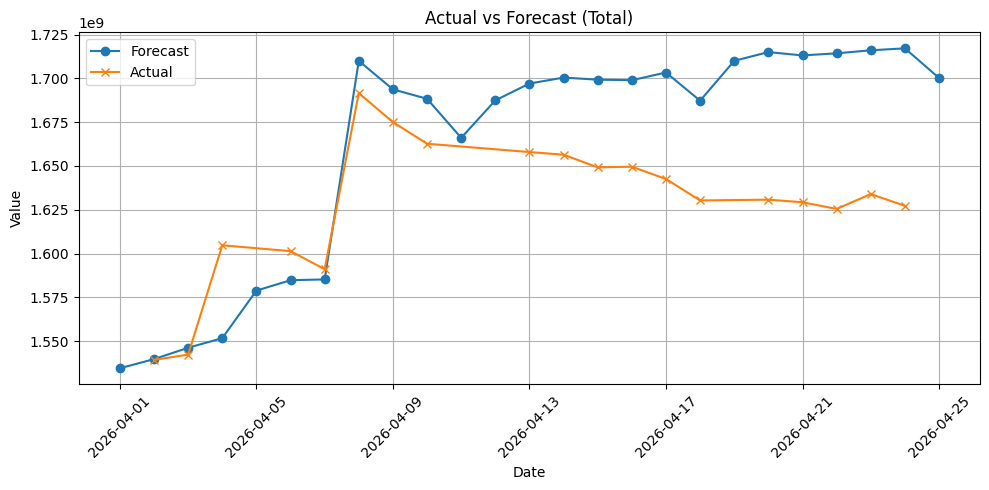

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(forecast_sum['Date'], forecast_sum['predicted_value'], marker='o', label='Forecast')
plt.plot(test_sum['Date'], test_sum['SumofPrincipalOutstanding'], marker='x', label='Actual')

plt.title("Actual vs Forecast (Total)")
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [33]:
merged = pd.merge(
    test_sum,
    forecast_sum,
    on='Date',
    how='inner'
)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = merged['SumofPrincipalOutstanding']
y_pred = merged['predicted_value']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape:.2f}%")

MAE: 45904611.70523495
RMSE: 54637045.86674274
MAPE: 2.81%
